# COGS 108 - EDA Checkpoint

## Authors

**Eric Badilla:** Conceptualization, Writing – original draft 

**Nishka Vaghela:** Background research, Writing – original draft 

**Niharika Sapre:** Software, visualization

**Renee Li:** Methodology, Writing – original draft 

**Jenny Fu:** Project administration, Software

# Research Question

What technical skills are demanded in tech and data roles, and how do skill demands, salary, and remote work availability differ across seniority levels?


## Background and Prior Work

Research has increasingly demonstrated the existence of a persistent gap between the skills learned within academic settings and the skills required within the labor market. According to the report on the Future of Work released by McKinsey (2023)(https://www.mckinsey.com/featured-insights/future-of-work/defining-the-skills-citizens-will-need-in-the-future-world-of-work), more than 40% of the global workforce could potentially require reskilling by the year 2030, with data and technical skills being the areas with the greatest growth rate in terms of demand. Similarly, the Future of Jobs reports released by the World Economic Forum have consistently ranked cloud computing, machine learning, and data analysis as the areas with the greatest growth rate in terms of demand for skills across all industries(https://www.weforum.org/publications/the-future-of-jobs-report-2023/). Although the aforementioned reports have demonstrated the existence of a persistent gap between the skills learned and the skills required within the labor market, they have not specifically examined the relationships between specific labor market outcomes and the skills learned by individuals, which could have a great impact on the decisions of new entrants into the labor market, particularly within the realm of the technical fields.

Some prior studies have already examined the job posting data to understand the skill demand in the tech labor market. To exemplify, the study by Sadafian (2026) examined the data from 1,964 LinkedIn job postings for data-related positions and discovered that the presence of SQL skills appeared in about 55% of the job postings, whereas the presence of Python skills appeared in about 41% of the job postings(https://www.kaggle.com/datasets/arshkon/linkedin-job-postings). Even though this study provides some insights into the labor market, it mainly provides a description of the data and lacks the exploration of the predictive power of the skills on the job posting outcomes. Another study on the LinkedIn Economic Graph(https://economicgraph.linkedin.com/) provides some insights into the labor market trends through the analysis of the LinkedIn data and provides some insights into the labor market trends. However, the study lacks the provision of individual-level job posting data to examine the predictive power of the skills on the job posting outcomes. Therefore, the gap in the literature lies in the exploration of the predictive power of the skills on the job posting outcomes.

The rise of the use of remote work after the year 2020 is an additional factor that can be analyzed. Technical work, such as technology and data work, has maintained the flexibility of working remotely more compared to other industries. This may imply that the nature of technical work is more conducive to flexibility. However, it has been argued that the fact that technology work is done remotely may be attributed to the nature of the work, which is digital-based, or it may be attributed to the fact that companies compete for the best talent. However, the investigation of the nature of the work may provide more clarity regarding the fact that the flexibility of working remotely may be attributed to the nature of the skills, the nature of the organizations, or the nature of the labor market.

Although the data obtained from LinkedIn is useful in understanding hiring trends in the technology industry, it is important to note that it only reflects a fraction of the entire hiring process in the labor market. This is because LinkedIn only accounts for a quarter of the entire online job board market and is biased towards mid-sized and large companies and established technology firms. This means that hiring trends in startup companies are often found on other job search websites like Wellfound, trades and health-related positions are common on websites like Indeed, and some small businesses may not even post their job vacancies online at all. It is thus important to understand that the results obtained from the job postings only reflect hiring trends in corporate technology and data industries.


# Hypothesis


We hypothesize the following:

Python, SQL, and cloud platform skills (AWS/GCP/Azure) will be the three most demanded skills across tech and data roles postings, with Python dominating data science roles and SQL dominating analyst roles. Roles requiring cloud and ML skills will show statistically significantly higher median salaries than roles requiring only general programming skills, after controlling for experience level and company size.
Remote work availability will be positively and significantly associated with roles requiring ML and cloud skills, reflecting the skew of those roles toward tech-forward companies. A classifier trained on skill profiles alone will achieve meaningful predictive accuracy for remote classification.
Skill demand will show a measurable upward trend for cloud and ML skills between 2020 and 2024, and a relative plateau or decline for general office tools like Excel.

## Data

### Data overview

Data Overview/Relevance (detailed description and trends dataset)
This project uses two publicly available datasets to investigate technical skill demand, compensation, and remote work patterns in tech and data roles.
Dataset #1: LinkedIn Jobs and Skills 2024
Dataset Name: LinkedIn Jobs and Skills 2024
Link: https://www.kaggle.com/datasets/asaniczka/1-3m-linkedin-jobs-and-skills-2024/code
Number of observations: Over 1.3 million job postings
Key variables: job title, required skills, seniority level, salary range, work type (remote/hybrid/on-site), company name, location
Shortcomings: LinkedIn represents only a fraction of the total job market and is skewed toward mid-sized and large companies. Roles filled through referrals, internal hiring, or campus recruiting are not captured.
 
Dataset #2: Latest Data Science Job Salaries 2024
Dataset Name: Latest Data Science Job Salaries 2024
Link: https://www.kaggle.com/datasets/saurabhbadole/latest-data-science-job-salaries-2024?resource=download
Key variables: salary_in_usd, experience_level (EN/MI/SE/EX), employment_type, job_title, remote_ratio (0/50/100), company_location, company_size
Shortcomings: Compiled from publicly available salary records; likely overrepresents companies with salary transparency policies. Job titles vary widely across the industry, requiring normalization before analysis.

The two datasets will be combined by aligning seniority level and job title fields. Dataset 1 provides skill demand and remote work data at scale, while Dataset 2 provides detailed salary benchmarks. Together they enable cross-referencing of skills, seniority, compensation, and work flexibility.


In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  50%|█████     | 1/2 [00:00<00:00,  6.33it/s]   

Successfully downloaded: airline-safety.csv



Overall Download Progress: 100%|██████████| 2/2 [00:00<00:00,  6.01it/s]

Successfully downloaded: bad-drivers.csv


### DATASET 1(LinkedIn Jobs and Skills 2024) 

 https://www.kaggle.com/datasets/asaniczka/1-3m-linkedin-jobs-and-skills-2024/code

The LinkedIn Jobs and Skills 2024 dataset contains over 1.3 million job postings collected from LinkedIn. Each row represents a single job posting and includes information such as job title, skills, seniority level, salary estimates, remote or work type, company name, and location. This makes the dataset useful for studying hiring patterns across many roles, industries, and locations.

The most important variables for this project are job title, skills, seniority level, salary information, and work type / remote status. The job title identifies the position being advertised, such as Data Scientist or Software Engineer. The skills field lists the technical and professional skills requested by employers, which helps show which tools and technologies are most in demand. The seniority level variable indicates the experience level required for the role, such as Entry-level, Associate, Mid-Senior, Director, or Executive. Salary information, when available, provides estimated pay ranges, and work type / remote status shows whether the job is on-site, hybrid, or fully remote.

These variables are important because they allow the dataset to capture both skill demand and job characteristics in the same posting. For example, the dataset can be used to compare which skills appear most often in tech and data roles, how those skills change across career stages, and whether salary and remote-work opportunities differ by seniority level.

There are also some concerns with this dataset. First, it only includes jobs posted on LinkedIn, so it may not represent the entire job market. Second, some fields, especially salary information, may be missing or inconsistent across postings. Third, skills may be listed in different formats or spellings, which means they may need additional cleaning before analysis. Despite these limitations, the dataset is well suited for this project because it provides detailed posting-level information on skills, seniority, salary, and remote work.


In [3]:
import pandas as pd
import numpy as np
import os

# -----------------------------
# 1. Load the dataset
# -----------------------------
file_path = "data/00-raw/linkedin_jobs_skills_2024.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

# -----------------------------
# 2. Demonstrate dataset size
# -----------------------------
print("Dataset shape (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns)

# -----------------------------
# 3. Check if dataset is tidy
# -----------------------------
# In a tidy dataset:
# - Each row = one job posting
# - Each column = one variable
# - Each cell = one value
print("\nPreview of dataset:")
print(df.head())

# -----------------------------
# 4. Check for null columns
# -----------------------------
null_counts = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": null_counts,
    "Percent Missing": null_percent
    })

print("\nMissing data summary:")
print(missing_summary.sort_values(by="Percent Missing", ascending=False))

# -----------------------------
# 5. Identify columns that are entirely null
# -----------------------------
null_columns = df.columns[df.isnull().all()]
print("\nColumns with all null values:")
print(null_columns)

# -----------------------------
# 6. Inspect patterns of missingness
# -----------------------------
# Checking whether missingness correlates with other columns
print("\nMissing values by column:")
print(df.isnull().sum())

# -----------------------------
# 7. Check data types
# -----------------------------
print("\nData types:")
print(df.dtypes)

# Convert salary columns to numeric if necessary
salary_cols = [col for col in df.columns if "salary" in col.lower()]

for col in salary_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# -----------------------------
# 8. Detect suspicious values / outliers
# -----------------------------
for col in salary_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(f"\nOutliers detected in {col}: {len(outliers)}")

# -----------------------------
# 9. Remove rows missing critical information
# -----------------------------
# For this project we require job title, skills, and seniority
critical_cols = [col for col in df.columns if any(x in col.lower() for x in ["title","skill","senior"])]

df_clean = df.dropna(subset=critical_cols)

# -----------------------------
# 10. Remove duplicate job postings
# -----------------------------
df_clean = df_clean.drop_duplicates()

# -----------------------------
# 11. Basic cleaning of skills column
# -----------------------------
skills_cols = [col for col in df_clean.columns if "skill" in col.lower()]

for col in skills_cols:
    df_clean[col] = df_clean[col].astype(str).str.lower().str.strip()

# -----------------------------
# 12. Summary statistics for important variables
# -----------------------------
print("\nSummary statistics:")
print(df_clean.describe(include='all'))

# -----------------------------
# 13. Demonstrate final dataset size
# -----------------------------
print("\nFinal cleaned dataset shape:", df_clean.shape)

# -----------------------------
# 14. Save processed dataset
# -----------------------------
os.makedirs("data/02-processed", exist_ok=True)
df_clean.to_csv("data/02-processed/linkedin_jobs_clean.csv", index=False)

print("\nClean dataset saved to data/02-processed/")



Dataset loaded successfully.
Dataset shape (rows, columns): (860050, 2)

Column names:
Index(['job_link', 'job_skills'], dtype='object')

Preview of dataset:
                                            job_link  \
0  https://www.linkedin.com/jobs/view/housekeeper...   
1  https://www.linkedin.com/jobs/view/assistant-g...   
2  https://www.linkedin.com/jobs/view/school-base...   
3  https://www.linkedin.com/jobs/view/electrical-...   
4  https://www.linkedin.com/jobs/view/electrical-...   

                                          job_skills  
0  Building Custodial Services, Cleaning, Janitor...  
1  Customer service, Restaurant management, Food ...  
2  Applied Behavior Analysis (ABA), Data analysis...  
3  Electrical Engineering, Project Controls, Sche...  
4  Electrical Assembly, Point to point wiring, St...  

Missing data summary:
            Missing Values  Percent Missing
job_skills             929         0.108017
job_link                 0         0.000000

Columns with all nu

### DATASET 2(Latest Data Science Job Salaries 2024): 

 https://www.kaggle.com/datasets/saurabhbadole/latest-data-science-job-salaries-2024?resource=download

The Latest Data Science Job Salaries 2024 dataset contains salary and job information for data-related roles across multiple companies, countries, and experience levels. Each row represents one job record and includes variables such as salary, job title, experience level, company location, remote work ratio, and company size. This dataset is useful for analyzing compensation trends and employment patterns in the data science industry.

One of the most important variables is salary_in_usd, which records yearly salary in U.S. dollars. This variable is numerical and represents annual compensation for a given role. In general, lower values tend to reflect entry-level jobs, while higher values are more common in senior or specialized roles. Because salaries are already converted into U.S. dollars, this variable makes comparisons across countries more meaningful.

Another key variable is experience_level, which groups employees into four categories: Entry-level (EN), Mid-level (MI), Senior-level (SE), and Executive-level (EX). These categories represent different career stages and help show how salary and job characteristics vary by experience. The dataset also includes employment_type (such as full-time, part-time, contract, or freelance), job_title, and company_size (small, medium, or large).

The dataset also includes remote_ratio, which describes how much of the work is done remotely. This variable is measured as 0, 50, or 100, where 0 means fully in-person, 50 means hybrid, and 100 means fully remote. This is important for understanding differences in workplace flexibility across data-related jobs. Other useful variables include company_location and employee_residence, which describe geographic location.

There are several concerns with this dataset. First, it may not represent the entire job market because it is based on publicly available salary information rather than a random sample of all workers. This may overrepresent companies or countries where salary data is more available. Second, salary values can vary widely by company, location, and role, so some entries may appear unusually high or low. Third, job titles in data science are often inconsistent, so similar roles may appear under different names and may need additional cleaning or grouping. Despite these limitations, the dataset provides a useful overview of salary trends and employment characteristics in the data science field.



Dataset loaded successfully
Dataset shape: (93597, 11)
Number of rows: 93597
Number of columns: 11

Columns:
Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

Preview:
   work_year experience_level employment_type           job_title  salary  \
0       2025               MI              FT  Research Scientist  208000   
1       2025               MI              FT  Research Scientist  147000   
2       2025               SE              FT  Research Scientist  173000   
3       2025               SE              FT  Research Scientist  117000   
4       2025               MI              FT         AI Engineer  100000   

  salary_currency  salary_in_usd employee_residence  remote_ratio  \
0             USD         208000                 US             0   
1             USD         147000                 US

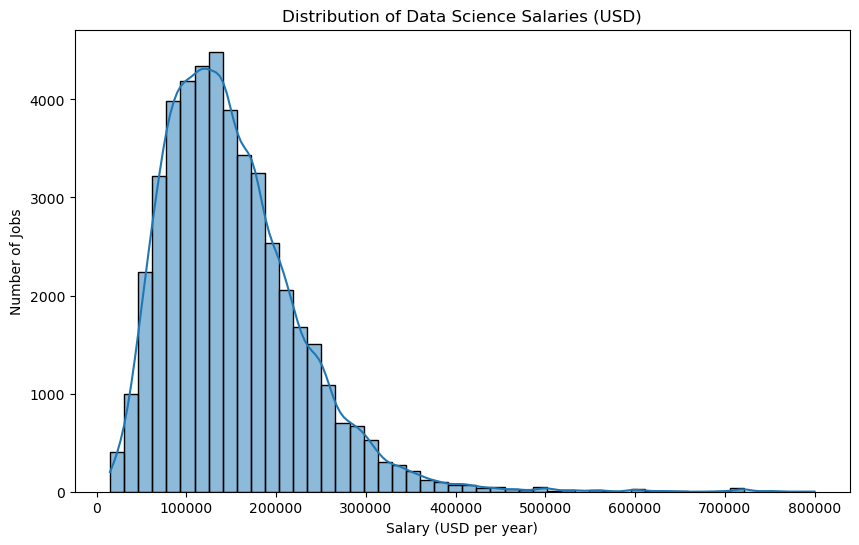

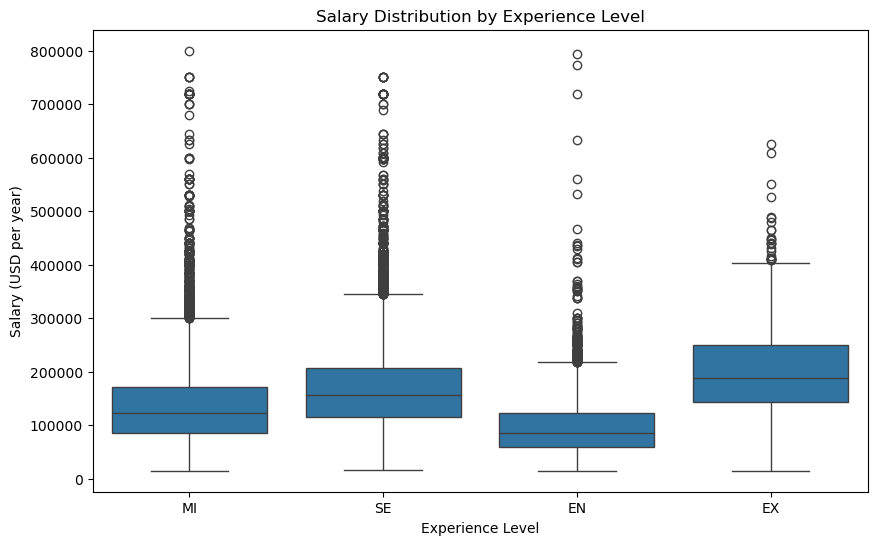

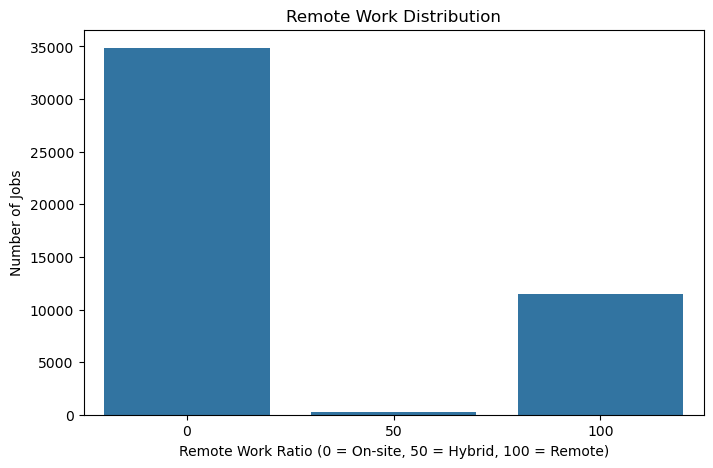

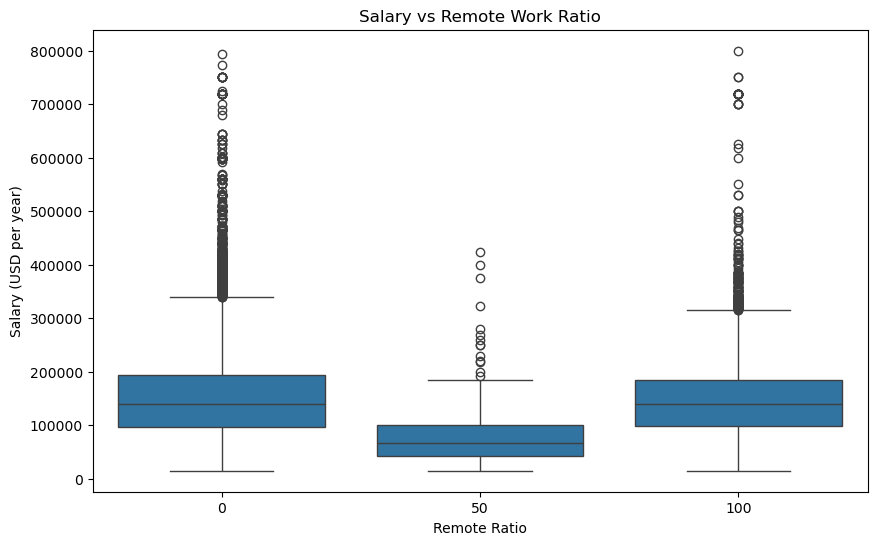

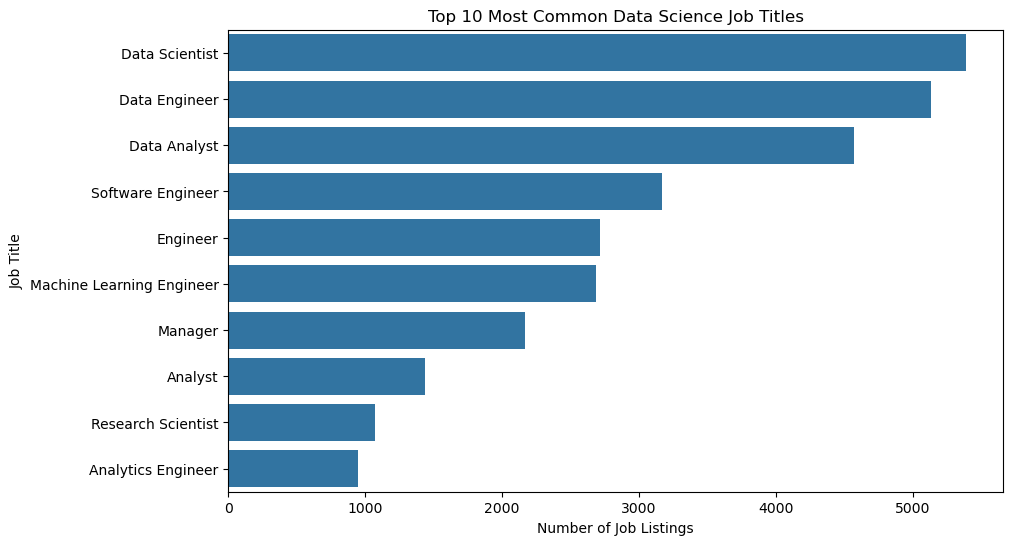

In [4]:
import pandas as pd
import numpy as np
import os

# -------------------------
# 1 Load the dataset
# -------------------------
df = pd.read_csv("data/00-raw/data_science_job_salaries.csv")

print("Dataset loaded successfully")

# -------------------------
# 2 Check dataset size
# -------------------------
print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# -------------------------
# 3 Inspect dataset structure
# -------------------------
print("\nColumns:")
print(df.columns)

print("\nPreview:")

print(df.head())

# -------------------------
# 4 Check if dataset is tidy
# -------------------------
# Each row = one job record
# Each column = one variable
# Each cell = one value
print("\nData types:")
print(df.dtypes)

# -------------------------
# 5 Missing data analysis
# -------------------------
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_counts,
    "Percent Missing": missing_percent
    })

print("\nMissing data summary:")
print(missing_summary)

# -------------------------
# 6 Check for fully null columns
# -------------------------
null_columns = df.columns[df.isnull().all()]
print("\nColumns that are completely null:")
print(null_columns)

# -------------------------
# 7 Detect suspicious values / outliers
# -------------------------
# Using IQR method for salary
Q1 = df["salary_in_usd"].quantile(0.25)
Q3 = df["salary_in_usd"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["salary_in_usd"] < lower) | (df["salary_in_usd"] > upper)]

print("\nPotential salary outliers:", len(outliers))

# -------------------------
# 8 Check unique categories
# -------------------------
print("\nExperience levels:")
print(df["experience_level"].unique())

print("\nEmployment types:")
print(df["employment_type"].unique())

print("\nRemote ratios:")
print(df["remote_ratio"].unique())

# -------------------------
# 9 Cleaning
# -------------------------
# Drop duplicate rows
df_clean = df.drop_duplicates()

# Remove rows missing critical information
critical_columns = ["salary_in_usd", "job_title", "experience_level"]
df_clean = df_clean.dropna(subset=critical_columns)

# Ensure salary is numeric
df_clean["salary_in_usd"] = pd.to_numeric(df_clean["salary_in_usd"], errors="coerce")

# -------------------------
# 10 Summary statistics
# -------------------------
print("\nSalary summary statistics:")
print(df_clean["salary_in_usd"].describe())

print("\nExperience level counts:")
print(df_clean["experience_level"].value_counts())

# -------------------------
# 11 Save processed dataset
# -------------------------
os.makedirs("data/02-processed", exist_ok=True)

df_clean.to_csv("data/02-processed/data_science_jobs_clean.csv", index=False)

print("\nCleaned dataset saved to data/02-processed/")


# -------------------------
# DATA VISUALISATION
# -------------------------



import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 1 Salary Distribution
# -------------------------
plt.figure(figsize=(10,6))
sns.histplot(df_clean["salary_in_usd"], bins=50, kde=True)
plt.title("Distribution of Data Science Salaries (USD)")
plt.xlabel("Salary (USD per year)")
plt.ylabel("Number of Jobs")
plt.show()


# -------------------------
# 2 Salary by Experience Level
# -------------------------
plt.figure(figsize=(10,6))
sns.boxplot(x="experience_level", y="salary_in_usd", data=df_clean)

plt.title("Salary Distribution by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Salary (USD per year)")
plt.show()


# -------------------------
# 3 Remote Work Distribution
# -------------------------
plt.figure(figsize=(8,5))
sns.countplot(x="remote_ratio", data=df_clean)

plt.title("Remote Work Distribution")
plt.xlabel("Remote Work Ratio (0 = On-site, 50 = Hybrid, 100 = Remote)")
plt.ylabel("Number of Jobs")
plt.show()


# -------------------------
# 4 Salary and Remote Work
# -------------------------
plt.figure(figsize=(10,6))
sns.boxplot(x="remote_ratio", y="salary_in_usd", data=df_clean)

plt.title("Salary vs Remote Work Ratio")
plt.xlabel("Remote Ratio")
plt.ylabel("Salary (USD per year)")
plt.show()


# -------------------------
# 5 Top 10 Most Common Job Titles
# -------------------------
top_jobs = df_clean["job_title"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_jobs.values, y=top_jobs.index)

plt.title("Top 10 Most Common Data Science Job Titles")
plt.xlabel("Number of Job Listings")
plt.ylabel("Job Title")
plt.show()




## Results

### Exploratory Data Analysis

In this section, exploratory data analysis (EDA) will be carried out to have a better idea about the data and the patterns within the datasets provided for this project. At this stage, the key variables like skills, salary, experience level, and working remotely are to be considered and analyzed before proceeding with the analysis. Here, the patterns and the distribution of the salaries with respect to the experience levels, the distribution of working remotely, and the overall data distribution are to be considered.

#### Section 1 of EDA - LinkedIn Job Postings Filtered for Tech

The first step in exploratory data analysis (EDA) is to understand the overall structure and quality of the dataset. This includes examining the dataset dimensions, inspecting column data types, and identifying missing values. Understanding these characteristics helps determine whether preprocessing steps such as cleaning or transformation are required.

In this section, we load the dataset and compute basic summary statistics. We also examine the distribution of categorical variables such as experience level and employment type to understand how the data is distributed across different job categories.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/00-raw/data_science_job_salaries.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

df.head()


Dataset Shape: (93597, 11)

Columns: Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

Missing Values:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,MI,FT,Research Scientist,208000,USD,208000,US,0,US,M
1,2025,MI,FT,Research Scientist,147000,USD,147000,US,0,US,M
2,2025,SE,FT,Research Scientist,173000,USD,173000,US,0,US,M
3,2025,SE,FT,Research Scientist,117000,USD,117000,US,0,US,M
4,2025,MI,FT,AI Engineer,100000,USD,100000,US,100,US,M


##### Interpretation

The summary statistics provide insight into salary ranges and variability across the dataset. For example, we can observe the average salary in USD and the spread between minimum and maximum salaries. This helps identify potential outliers and gives a first look at the salary distribution within data science roles.

Next, we examine the distribution of salaries across the dataset. Understanding the distribution helps determine whether salaries follow a normal distribution or are skewed. This is important when deciding which statistical techniques or machine learning models might be appropriate later.

We visualize the distribution using a histogram and boxplot.



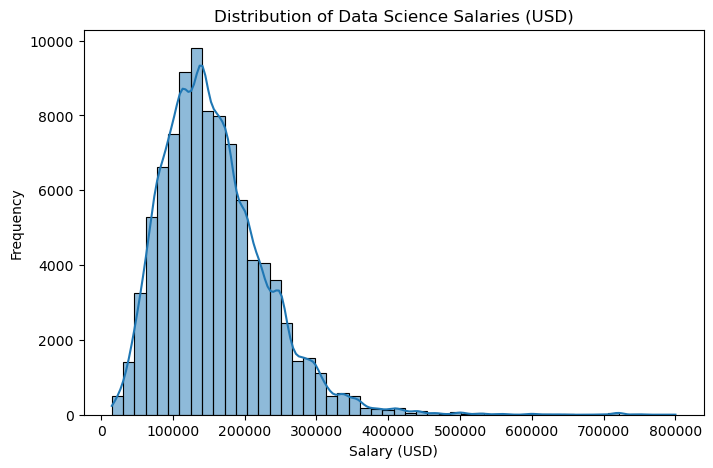

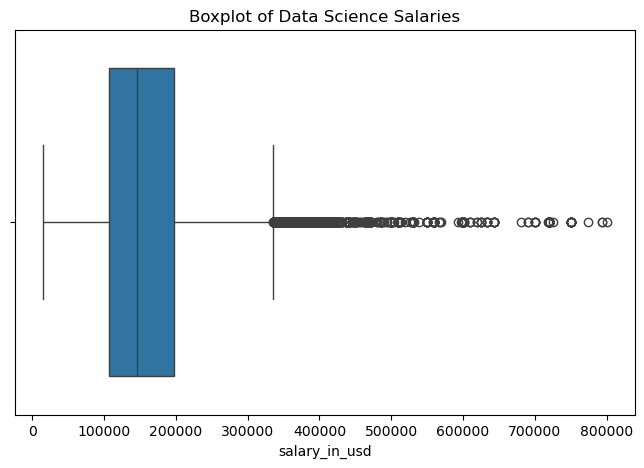

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["salary_in_usd"], bins=50, kde=True)

plt.title("Distribution of Data Science Salaries (USD)")
plt.xlabel("Salary (USD)")
plt.ylabel("Frequency")

plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df["salary_in_usd"])

plt.title("Boxplot of Data Science Salaries")
plt.show()


##### Interpretation

The histogram shows that salary values are typically right-skewed, meaning that while most salaries cluster around the middle range, there are some very high-paying positions that extend the upper tail of the distribution. The boxplot confirms the presence of outliers, which represent highly paid roles such as senior machine learning engineers or specialized AI researchers.



##### Explanation

Experience level is expected to have a strong influence on salary. In this section, we analyze how salaries differ across experience levels.


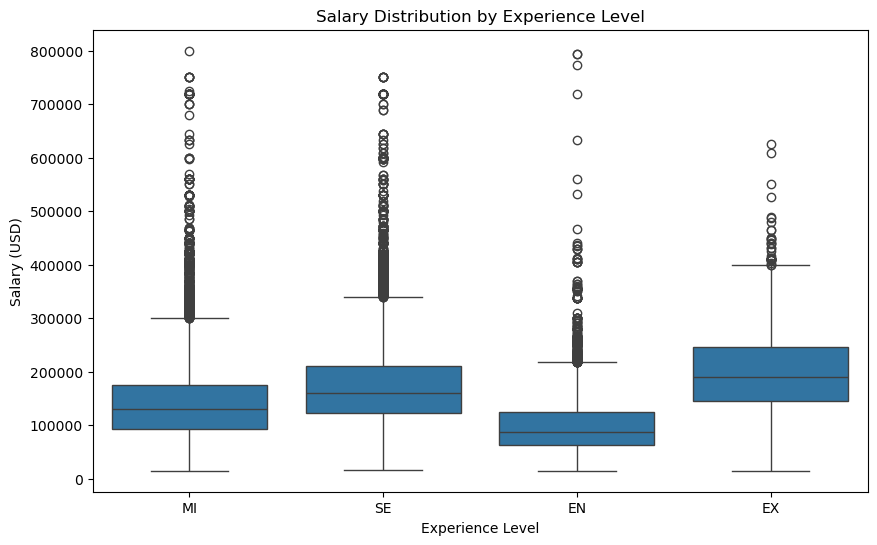

In [7]:
plt.figure(figsize=(10,6))

sns.boxplot(
x="experience_level",
y="salary_in_usd",
data=df
)

plt.title("Salary Distribution by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Salary (USD)")

plt.show()


##### Explanation

The boxplot shows that salaries increase with experience level. Entry-level roles generally have the lowest salaries, while senior and executive roles have significantly higher compensation. The spread of salaries also increases at higher experience levels, suggesting more variability depending on specialization and company.


##### Remote work Explanation

Remote work has become increasingly common in the technology industry. In this section, we explore whether remote jobs tend to offer higher or lower salaries compared to on-site roles.

The remote_ratio column typically represents:

0 = On-site

50 = Hybrid

100 = Fully remote


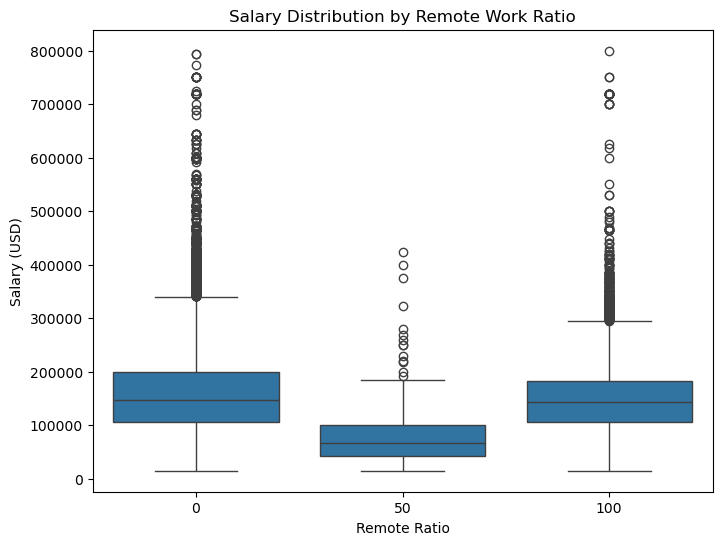

In [8]:
plt.figure(figsize=(8,6))

sns.boxplot(
x="remote_ratio",
y="salary_in_usd",
data=df
)

plt.title("Salary Distribution by Remote Work Ratio")
plt.xlabel("Remote Ratio")
plt.ylabel("Salary (USD)")

plt.show()



Example of Modularized Code:

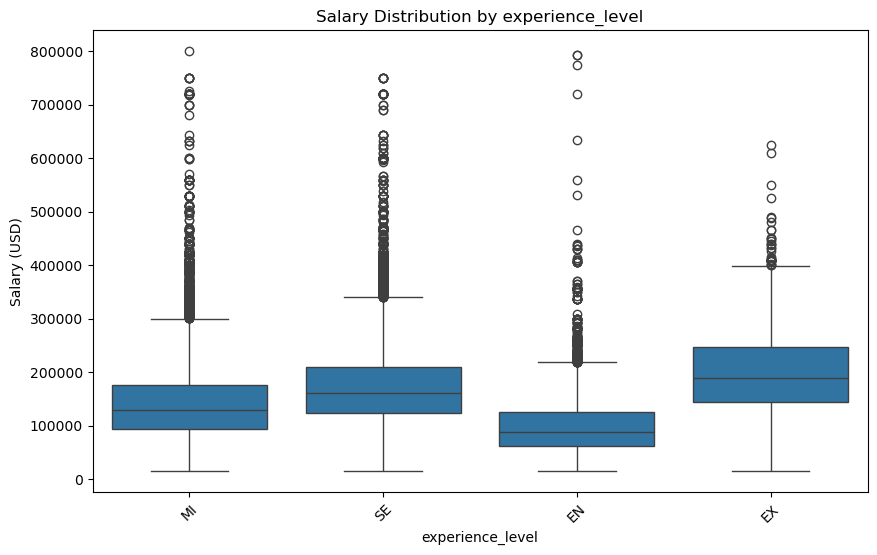

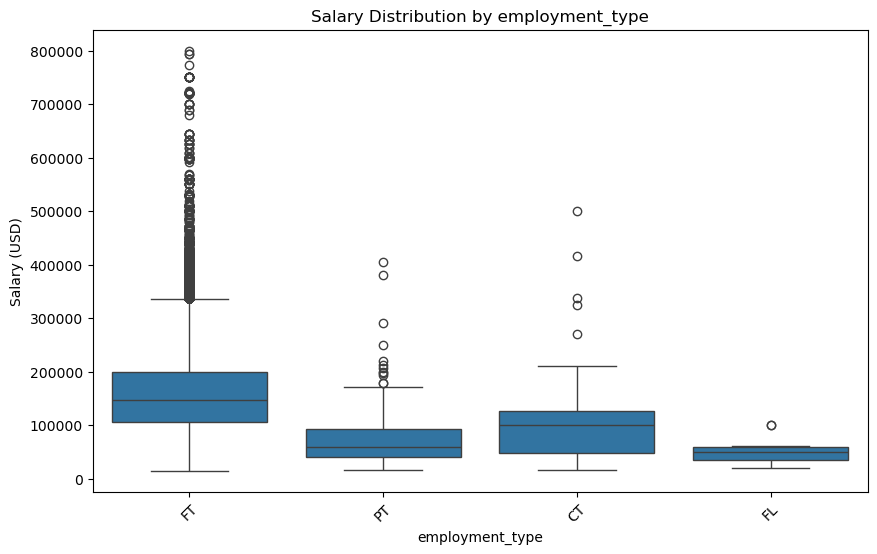

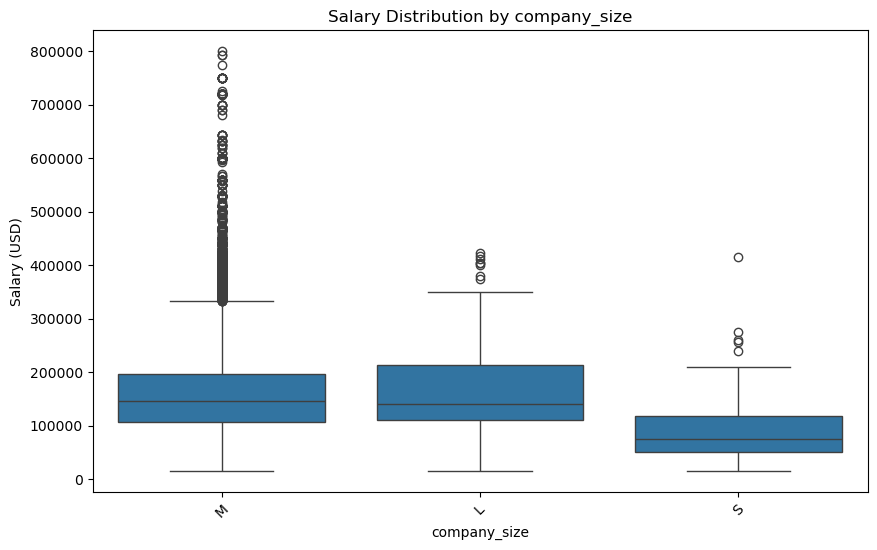

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_salary_by_category(df, category):
    plt.figure(figsize=(10,6))
    
    sns.boxplot(
        x=category,
        y="salary_in_usd",
        data=df
    )
    
    plt.title(f"Salary Distribution by {category}")
    plt.xlabel(category)
    plt.ylabel("Salary (USD)")
    
    plt.xticks(rotation=45)
    plt.show()

plot_salary_by_category(df, "experience_level")
plot_salary_by_category(df, "employment_type")
plot_salary_by_category(df, "company_size")

#### Section 2 of EDA - EDA for Latest Data Science Job Salaries 2024


This notebook performs exploratory data analysis (EDA) on the Kaggle dataset **Latest Data Science Job Salaries 2024**. 
The goal is to understand salary patterns across experience levels, remote work arrangements, and company characteristics.

Dataset source: https://www.kaggle.com/datasets/saurabhbadole/latest-data-science-job-salaries-2024

##### 1. Import Libraries and Load Dataset

First we import the required libraries and load the dataset into a pandas DataFrame.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/00-raw/data_science_job_salaries.csv')

print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (93597, 11)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,MI,FT,Research Scientist,208000,USD,208000,US,0,US,M
1,2025,MI,FT,Research Scientist,147000,USD,147000,US,0,US,M
2,2025,SE,FT,Research Scientist,173000,USD,173000,US,0,US,M
3,2025,SE,FT,Research Scientist,117000,USD,117000,US,0,US,M
4,2025,MI,FT,AI Engineer,100000,USD,100000,US,100,US,M


##### 2. Data Overview

Understanding the structure of the dataset helps identify missing values, data types, and potential preprocessing needs.

In [11]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93597 entries, 0 to 93596
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           93597 non-null  int64 
 1   experience_level    93597 non-null  object
 2   employment_type     93597 non-null  object
 3   job_title           93597 non-null  object
 4   salary              93597 non-null  int64 
 5   salary_currency     93597 non-null  object
 6   salary_in_usd       93597 non-null  int64 
 7   employee_residence  93597 non-null  object
 8   remote_ratio        93597 non-null  int64 
 9   company_location    93597 non-null  object
 10  company_size        93597 non-null  object
dtypes: int64(4), object(7)
memory usage: 7.9+ MB


work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

##### 3. Salary Distribution

We visualize how salaries are distributed across all jobs to understand whether the data is skewed and to identify possible outliers.

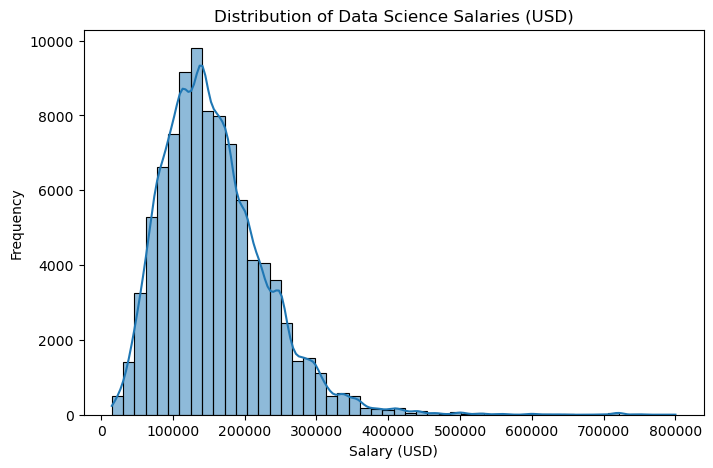

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['salary_in_usd'], bins=50, kde=True)

plt.title('Distribution of Data Science Salaries (USD)')
plt.xlabel('Salary (USD)')
plt.ylabel('Frequency')

plt.show()

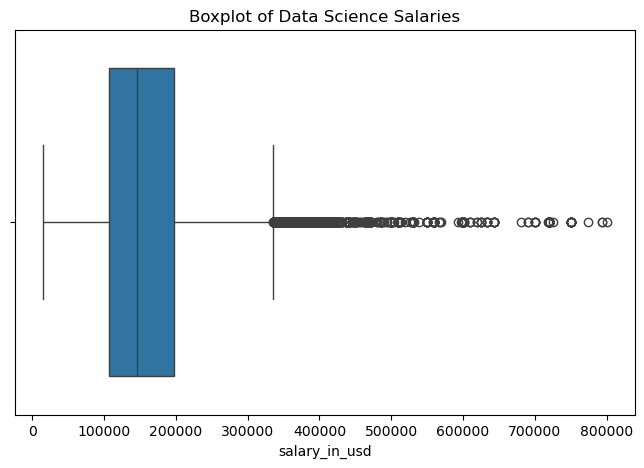

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['salary_in_usd'])

plt.title('Boxplot of Data Science Salaries')
plt.show()

##### 4. Salary vs Experience Level

Experience level is expected to strongly influence salary. We visualize salary distributions across different experience categories.

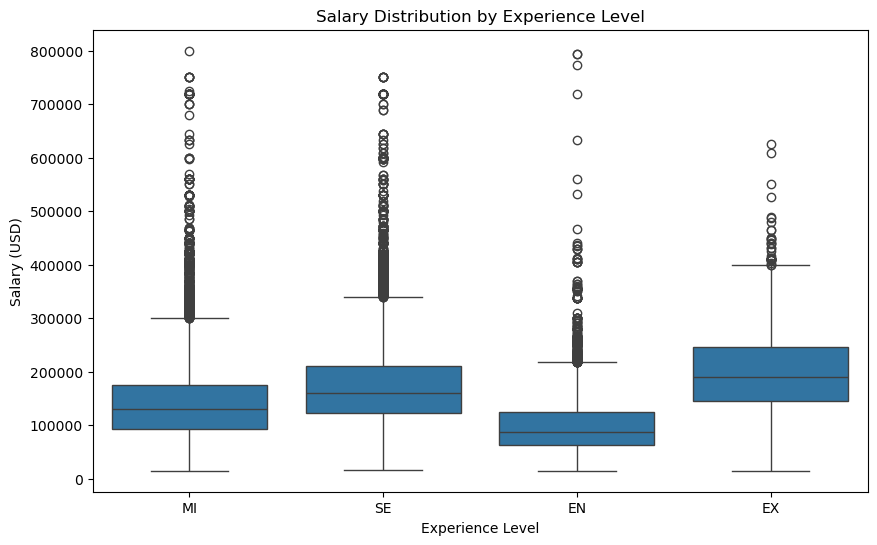

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(x='experience_level', y='salary_in_usd', data=df)

plt.title('Salary Distribution by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')

plt.show()

##### 5. Remote Work vs Salary

We explore whether remote jobs tend to offer different salaries compared to hybrid or on‑site roles.

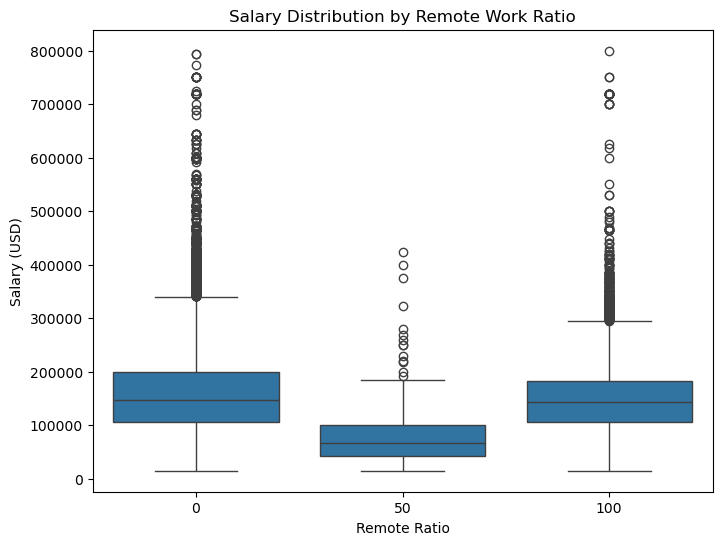

In [15]:
plt.figure(figsize=(8,6))
sns.boxplot(x='remote_ratio', y='salary_in_usd', data=df)

plt.title('Salary Distribution by Remote Work Ratio')
plt.xlabel('Remote Ratio')
plt.ylabel('Salary (USD)')

plt.show()

##### 6. Salary by Company Size

Company size may also influence salary levels. Larger companies sometimes have higher budgets for specialized roles.

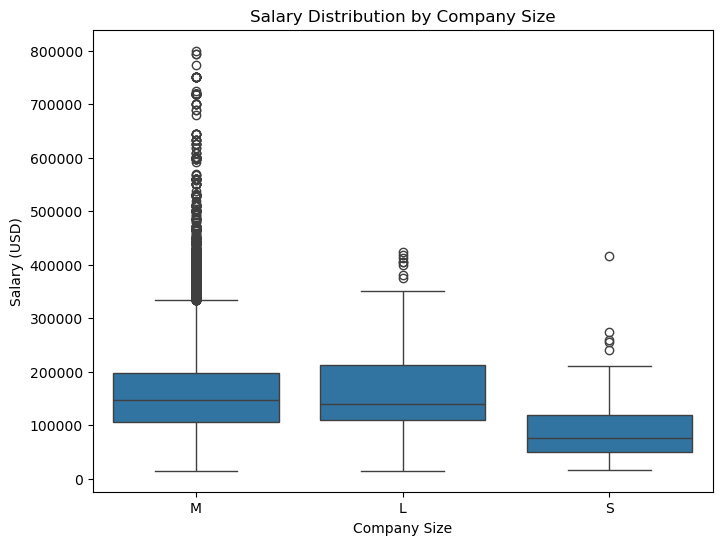

In [16]:
plt.figure(figsize=(8,6))
sns.boxplot(x='company_size', y='salary_in_usd', data=df)

plt.title('Salary Distribution by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Salary (USD)')

plt.show()

##### 7. Conclusion

From this exploratory analysis we can observe trends such as:

- Salary increases significantly with experience level.
- The salary distribution is right‑skewed due to high‑paying senior roles.
- Remote jobs often offer competitive salaries.
- Company size can influence compensation levels.

These insights can help guide further modeling or predictive analysis.

## Ethics

Instructions: Keep the contents of this cell. For each item on the checklist
-  put an X there if you've considered the item
-  IF THE ITEM IS RELEVANT place a short paragraph after the checklist item discussing the issue.
  
Items on this checklist are meant to provoke discussion among good-faith actors who take their ethical responsibilities seriously. Your teams will document these discussions and decisions for posterity using this section.  You don't have to solve these problems, you just have to acknowledge any potential harm no matter how unlikely.

Here is a [list of real world examples](https://deon.drivendata.org/examples/) for each item in the checklist that can refer to.

[![Deon badge](https://img.shields.io/badge/ethics%20checklist-deon-brightgreen.svg?style=popout-square)](http://deon.drivendata.org/)

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> Example of how to use the checkbox, and also of how you can put in a short paragraph that discusses the way this checklist item affects your project.  Remove this paragraph and the X in the checkbox before you fill this out for your project

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?
> We are concerned that the data itself may be biased or incomplete. Not all entry-level software engineering jobs are posted online, since some people get jobs through referrals, internal hiring, or campus recruiting that does not appear on job boards. Because of this, it is difficult to collect data that fully represents the true number of available jobs, which may affect the accuracy of the comparison.

 - [ ] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?
 - [ ] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
> The data used in this project is publicly available and does not include any private information. It is stored locally during the analysis, and basic care is taken to avoid accidentally changing or sharing the files. Because the data is low risk, no special security measures are needed.

 - [ ] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
 - [ ] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?
> This project looks at overall numbers and trends, so it does not include personal experiences from recent graduates or employers. Because of this, the results may not fully explain why certain trends happen, and they should be understood as showing general patterns rather than individual experiences.

 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?
> The datasets used in this analysis may introduce bias because they rely on broad categories and assumptions. Not all Computer Science graduates are looking for software engineering jobs, and not all jobs labeled as “entry-level” are actually accessible to new graduates. These mismatches can affect the comparison between supply and demand, so the results should be interpreted as approximate trends rather than exact measurements.

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?
> The results are presented in a way that avoids oversimplifying or exaggerating the data. Instead of focusing on single-year changes, the analysis looks at overall trends across multiple years to reduce the impact of short-term fluctuations. All figures and summaries are explained in context so readers understand what the data shows and what it does not show.

 - [ ] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?
 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?
> The steps of the analysis, including data sources and processing methods, are documented so that the work can be checked or repeated by others if needed, which also helps maintain transparency and accountability.


### D. Modeling
 - [ ] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
 - [ ] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
> The metrics used, such as the number of graduates and the number of entry-level job postings, were chosen because they directly relate to the research question. However, these metrics do not capture job quality or underemployment, which is a limitation.

 - [ ] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?
> The final results clearly explain the limitations of the analysis, including data gaps and simplifying assumptions, so readers understand what the results do and do not show.

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
> This analysis is based on data from a specific time period. If it were updated in the future, the data and methods would need to be checked again to make sure they still reflect current job market conditions.

 - [ ] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [ ] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?
> There is a possibility that the results could be misunderstood or used to discourage students from majoring in Computer Science. To reduce this risk, the analysis emphasizes that it describes overall trends in the job market and does not predict individual outcomes or career success.


## Team Expectations 

* *We will communicate primarily through messages for quick updates and questions, and use Google Docs for longer-form work and progress tracking. We will meet once per week (virtually) and schedule additional meetings as needed*
* *We agree to communicate in a blunt but polite manner. Team members should feel comfortable expressing disagreement or concerns respectfully and constructively*
* *For major project decisions, we will aim for consensus. Otherwise, by majority vote. If in cases of time-sensitive decisions, the member will have to make a temporary decision at the moment and inform the group*
* *Tasks will be divided based on individual choices as they want. We will track tasks and progress using a shared document, so responsibilities and deadlines are visible to everyone.*
* *We will follow the agreed-upon project timeline and update it as needed. Team members are expected to complete assigned tasks by internal deadlines so the group can double-check.*
* *If a team member is struggling to complete a task, they should notify the group as early as possible, so we can work together to redistribute work temporarily or provide support. If a member consistently misses deadlines without communication, the group will address the issue directly and follow course guidelines if needed.*
* *All team members are expected to contribute equally in effort, communicate regularly, and respect each other’s time and commitments. We recognize that everyone has different strengths, schedules, and working styles, and we will support one another to ensure the project progresses smoothly.*

## Project Timeline Proposal

| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 2/4  |  1 PM | Review COGS 108 project expectations; brainstorm project ideas related to Big Tech hiring  | Determine best form of communication; Discuss and decide on final research question; discuss hypothesis; begin background research | 
| 2/11  |  10 AM |  Do background research on CS graduate trends and Big Tech hiring patterns | Identify potential datasets (education + job postings) and ethics; draft project proposal | 
| 2/18  | 10 AM  | Edit, finalize, and submit proposal; Search for datasets  | Discuss Wrangling and possible analytical approaches; Assign group members to lead each specific part   |
| 2/25  | 6 PM  | Import & Wrangle Data; EDA | Review/Edit wrangling/EDA; Discuss Analysis Plan   |
| 3/4  | 12 PM  | Finalize wrangling/EDA; Begin Analysis | Discuss/edit Analysis; Complete project check-in |
| 3/11  | 12 PM  | Complete analysis; Draft results/conclusion/discussion| Discuss/edit full project |
| 3/18  | Before 11:59 PM  | double check assigned parts is completed and polished | Turn in Final Project & Group Project Surveys |
